<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/25.2%20TEMA/Trabalho%202/tema2_2025_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho 2 - *TEMA 2025/2***

## **Universidade de Brasília** - *Faculdade de Ciências e Tecnologias em Engenharia*

## *Segundo Trabalho de Tópicos Especiais em Matemática Aplicada - 2025/2*

- Docente: Vinícius de Carvalho Rispoli

- Discente: Eduardo de Pina Moreira Santos

- Matrícula: 231034494

## **Sumário**

1. [***Introdução***](#1.)
2. [***Metodologia***](#2.)
3. [***Análise e Tratamento do Dataset***](#3.)
4. [***Encoder***](#4.)
5. [***Decoder***](#5.)
6. [***Teste, Comparação e Resultados***](#6.)
7. [***Conclusão***](#7.)
8. [***Referências***](#8.)

<a name="1."></a>
## **1. Introdução**

Este trabalho corresponde ao projeto desenvolvido para a segunda atividade avaliativa da disciplina de *Tópicos Especiais em Matemática Aplicada* na **UnB**. Nesse sentido, a fim de desenvolver o conhecimento dos estudantes no que tange a modelos de linguagem utilizando o *Pytorch*, foi proposto que desenvolvessem um modelo *Encoder-Decoder* para a tarefa de legendagem automática de imagens.

Também foi requisitado que fosse elaborada uma comparação entre três arquiteturas de *decoder*: **LSTM**, **GRU** e **Transformador**. Todas as três utilizariam, como base, um mesmo *encoder* pré-treinado do *PyTorch* para extração de um vetor de características da imagem. O *Dataset* que deve ser utilizado é o **Flickr8k**, composto por 8.092 imagens, sendo cada uma associada a 5 legendas diferentes.

Antes de iniciar esse desenvolvimento, foi elaborada a metodologia a ser seguida no projeto, definida no tópico [*2. Metodologia*](#2.).

<a name="2."></a>
## **2. Metodologia**

A primeira etapa do desenvolvimento do projeto consistiu na elaboração de uma metodologia "parcial" eficiente, para ser seguida no contexto do problema. Essa metodologia pôde ser dividida em **6 fases** principais, listadas e descritas abaixo:

### 1. *Entendimento do Problema e do Dataset*

- A fase inicial consistiu no entendimento do material disponibilizado para o trabalho. Após a leitura do comando e um processo de observação das imagens e das legendas, foi feito um *brainstorming* para o entendimento de como seria desenvolvido o projeto.


### 2. *Pesquisa e Levantamento de Informações*

- Seguindo a etapa de *brainstorming*, foi feita uma busca extensiva de dados na *internet*, em veículos acadêmicos e em *chatbots*, com o intuido de separar e organizar as ferramentas mais adequadas para o projeto, além de uma série de outras informações para o ampliar o conhecimento e proporcionar um desenvolvimento mais limpo e mais consciente do trabalho.

### 3. *Preparação do Dataset e do Encoder*

- Depois, com auxílio do material obtido na etapa de pesquisa, iniciou-se a montagem do *notebook* com o código para a importação e pré-processamento do *Dataset*, assim como a escolha do *encoder* e importação do mesmo no *Colab*.

### 4. *Montagem e treinamento dos Decoders*

- Com a preparação do *Dataset* e do *Encoder*, na etapa anterior, seguiu-se para o desenvolvimento dos modelos que seriam utilizados na análise e comparação do projeto: os *Decoders* *"LSTM"*, *"GRU"* e *"Transformer"*. Para todos os três, foi construída uma classe, e depois realizados uma série de testes de treinamento sobre essa classe, até que se obtivessem resultados satisfatórios.

### 5. *Teste e comparação de resultados*

- Após o desenvolvimento bem-sucedido dos *Decoders*, bem como seus treinamentos, o próximo passo consistiu na obtenção de métricas de teste (por meio de um conjunto dedicado), para comparação direta e justa entre os três modelos desenvolvidos. Assim, os resultados dessa comparação foram observados e analisados, para que fizessem parte da análise pretendida no projeto.

### 6. *Organização do código e divisão dos tópicos*

- Por fim, com o código finalizado, seguiu-se para uma etapa de organização do mesmo, removendo trechos desnecessários e melhorando a visualização, de divisão e separação dos tópicos no notebook e, ao final, de elaboração dos textos explicativos.

<br>

Após a elaboração parcial da **metodologia**, iniciou-se todo o desenvolvimento representado nela. Para acompanhar o resultado desse desenvolvimento, siga para o primeiro tópico prático do trabalho: [*3. Análise e Tratamento do Dataset*](#3.).

<a name="3."></a>
## **3. Análise e Tratamento do Dataset**

Nesse tópico, vamos iniciar o trabalho com a importação, análise e tratamento do conjunto de dados que alimentará o modelo de *image captioning*: o *Flickr8k Dataset* [¹](#8.). Ele é composto por:

- ***8.092** imagens selecionadas da plataforma flickr;*
- ***40.460** legendas, sendo 5 para cada imagem;*

Começaremos importando os módulos necessários, no tópico a seguir.

<a name="3.1."></a>
### *3.1. Importações*

Primeiramente, importaremos os módulos do Pytorch e as bibliotecas diversas do Python que serão utilizadas ao longo do código.

In [ ]:
# Importação de bibliotecas do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


# Importação de bibliotecas diversas
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from collections import Counter, defaultdict
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import random
import math
import re
import os

import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Depois, fazemos o download dos arquivos contendo o *diretório de imagens* e o *.txt com as legendas*, diretamente do *GitHub* [¹](#8.) :

In [ ]:
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip -O images.zip
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip -O captions.zip

!unzip images.zip -d /content/flickr8k > /dev/null
!unzip captions.zip -d /content/flickr8k > /dev/null

--2025-12-05 12:44:45--  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/124585957/47f52b80-3501-11e9-8f49-4515a2a3339b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-05T13%3A38%3A06Z&rscd=attachment%3B+filename%3DFlickr8k_Dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-05T12%3A37%3A21Z&ske=2025-12-05T13%3A38%3A06Z&sks=b&skv=2018-11-09&sig=DtbhFBRQPzhGiQu%2FeCTD0YYbdTNJNllBW%2BwJ9H58bfg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NDk0MjI4NSwibmJmIjoxNzY0OTM4Njg1LCJwYXRoIjoicmVsZWFzZWFzc2V

Por fim, definimos os paths para esses locais, que serão utilizados ao longo do código.

In [ ]:
images_path = '/content/flickr8k/Flicker8k_Dataset' # Diretório das imagens
captions_path = '/content/flickr8k/Flickr8k.lemma.token.txt' # TXT das legendas

save_path  = "/content/flickr8k/models" # Diretório de output de modelos
os.makedirs(save_path, exist_ok=True) # Cria o diretório de output

<a name="3.2."></a>
### *3.2. Análise*

Aqui, faremos uma breve análise das imagens e de uma amostra das legendas "raw", disponíveis no *Dataset*.

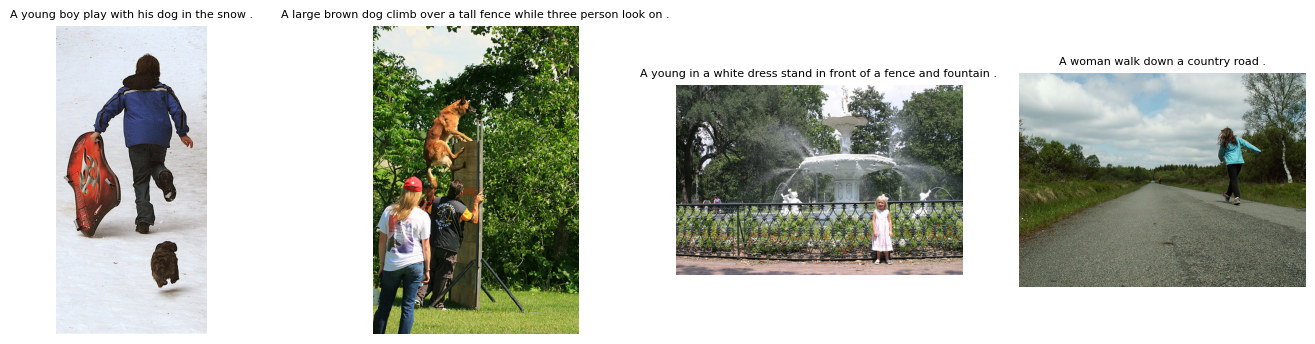

In [ ]:
with open(captions_path, 'r') as file:
  image_ids = file.read().splitlines()

random_images = random.sample(image_ids, 4)
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for i, image_id in enumerate(random_images):
  image_path = os.path.join(images_path, image_id.split('#')[0])
  img = Image.open(image_path)

  axes[i].imshow(img), axes[i].axis('off')
  axes[i].set_title(image_id.split('#')[1][2:], fontsize=8)

Com base nas amostras geradas, é possível aferir alguns pontos:

- As imagens possuem proporções diversas;
- As imagens possuem o canal de cores RGB;
- As legendas resumem, de forma objetiva, o principal evento da imagem;
- As legendas podem possuir pontuação, espaços, letras maiúsculas e apóstrofos.

Essas características, dentre outras, apontam para a necessidade de um processamento de dados, uma vez que tanto modelos que trabalham com imagens quanto os que trabalham com textos tendem a trabalhar com valores padronizados.

Além disso, é importante perceber também que um aumento de dados (*data augmentation*) pode ser bem vindo no contexto do problema. Mesmo com uma quantidade aceitável de imagens, o desempenho do modelo pode ser muito superior assim.

<a name="3.3."></a>
### *3.3. Definições*

Nesse tópico, vamos definir valores e as classes e métodos que serão utilizados no pré-processamento de dados e no *data augmentation*.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224

random_seed = 42 # Semente de aleatorização
batch_size = 32 # Tamanho do lote de treinamento
val_ratio = 0.2 # Proporção do dataset para validação
test_ratio = 0.2 # Proporção do dataset para teste

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_workers = 0

In [ ]:
# Classe para construção dos Datasets (base dos Dataloaders)
class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_dict, image_ids, vocab, transform=None, mode='train', max_length=50):
        self.image_dir = image_dir
        self.captions = captions_dict
        self.image_ids = image_ids
        self.vocab = vocab
        self.transform = transform
        self.mode = mode
        self.max_length = max_length

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, img_id)
        image = Image.open(img_path).convert("RGB") # load image

        if self.transform is not None:  image = self.transform(image)

        caps = self.captions[img_id] # select caption
        if self.mode == 'train': raw_caption = random.choice(caps)
        else: raw_caption = caps[0]

        tokens = word_tokenize(raw_caption)
        tokens = ['<start>'] + tokens[:self.max_length-2] + ['<end>'] # add start and end tokens
        numeric = torch.tensor(self.vocab.numericalize(tokens), dtype=torch.long)
        return image, numeric, img_id


# Classe para construção do vocabulário
class Vocabulary():
    def __init__(self, reserved_tokens, min_freq=5):
        self.min_freq = min_freq
        self.reserved_tokens = reserved_tokens
        self.stoi, self.itos = {}, []

    def build(self, captions_dict):
        counter = Counter()

        for caps in captions_dict.values():
            for c in caps:
                tokens = word_tokenize(c)
                counter.update(tokens)
        self.itos = list(self.reserved_tokens)

        for word, freq in counter.most_common():
            if freq < self.min_freq: break
            if word in self.itos: continue
            self.itos.append(word)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def numericalize(self, tokens):
        unk = self.stoi.get('<unk>')
        return [self.stoi.get(t, unk) for t in tokens] # tokens: list of tokens (strings)

    def decode(self, indices):
        return [self.itos[i] if i < len(self.itos) else '<unk>' for i in indices]


# Função de preenchimento de batch
def collate_fn(batch):
  images, captions, img_ids = zip(*batch)
  images = torch.stack(images, dim=0)
  lengths = [cap.size(0) for cap in captions]
  captions_padded = pad_sequence(captions, batch_first=True, padding_value=0)
  return images, captions_padded, torch.tensor(lengths, dtype=torch.long), list(img_ids)


# Função para ajuste/limpeza das legendas
def clean_caption(line):
  line = line.strip().lower()
  line = re.sub(r"[^a-z0-9'\s]", " ", line)
  line = re.sub(r"\s+", " ", line).strip()
  return line

Aqui, definimos os transforms que serão utilizados nos *Data Loaders*:

- **Teste e Validação**: Transforms básicos (resize, tensorização, normalização)
- **Treinamento**: Básicos + Cortes, giros e mudança de cores;

**Obs:** *A normalização segue os valores de desvio e de média padrões do ImageNet, e os resizes seguem o tamanho padrão dos modelos do Pytorch (224x224). Todos esses valores foram definidos na primeira célula do tópico anterior.*

In [ ]:
# Transforms de treinamento
train_transform = transforms.Compose([
  transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
  transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
  transforms.RandomHorizontalFlip(),
  transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
  transforms.ToTensor(),
  transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transforms de validação e teste
val_test_transform = transforms.Compose([
  transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
  transforms.CenterCrop(IMAGE_SIZE),
  transforms.ToTensor(),
  transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

<a name="3.4."></a>
### *3.4. Pré-Processamento*

Depois das definições, iniciaremos o pré-processamento das legendas e imagens.

Nesse momento, separaramos as legendas em um dicionário organizado, e tratamos os textos removendo caracteres indesejados e letras maiúsculas. Além disso, dividimos os *ids* (nomes) das imagens para **treino**, **teste** e **validação**, conforme a razão definida anteriormente.

In [ ]:
# Constrói um dicionário {id: [cap0, cap1, ...]} a partir do .txt de legendas
captions = defaultdict(list)
with open(captions_path, 'r', encoding='utf-8') as f:
  for line in f:
    line = line.strip()

    if len(line) == 0: continue
    try: img_token, caption = line.split('\t')
    except ValueError: continue

    id = img_token.split('#')[0]
    c = clean_caption(caption)
    captions[id].append(c)

# Remove um id sem correspondência no diretório de imagens
del captions['2258277193_586949ec62.jpg.1']

# Ordena e embaralha os ids das imagens
image_ids = sorted(list(captions.keys()))
random.seed(random_seed), random.shuffle(image_ids)

# Número de elementos de teste, validação e treinamento
n_test  = int(len(image_ids) * test_ratio)
n_val   = int(len(image_ids) * val_ratio)
n_train = len(image_ids) - n_val - n_test

# ID's dos elementos de treinamento, validação e teste
train_ids = image_ids[:n_train]
val_ids   = image_ids[n_train:n_train + n_val]
test_ids  = image_ids[n_train + n_val:]

Depois, prosseguimos para a construção do vocabulário com auxílio da classe definida no tópico anterior. O vocabulário será um mapa entre as palavras existentes no universo de legendas, e números, os quais a rede utilizará. Também, definimos os *Data Loaders* do *Pytorch* na proporção desejada.

In [ ]:
# Monta o Vocabulário
train_captions = {k: captions[k] for k in train_ids}
vocab = Vocabulary(reserved_tokens=['<pad>', '<start>', '<end>', '<unk>'], min_freq=5)
vocab.build(train_captions)
vocab_size = len(vocab)

# Monta os Datasets
train_dataset = Flickr8kDataset(images_path, captions, train_ids, vocab, transform=train_transform, mode='train')
val_dataset   = Flickr8kDataset(images_path, captions, val_ids, vocab, transform=val_test_transform, mode='val')
test_dataset  = Flickr8kDataset(images_path, captions, test_ids, vocab, transform=val_test_transform, mode='test')

# Monta os Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,
                          collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
                          collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
                          collate_fn=collate_fn, pin_memory=True)

# Log
print(f"train = {len(train_ids)}, val = {len(val_ids)}, test = {len(test_ids)}, total = {len(image_ids)}\nvocab_size = {vocab_size}")

train = 4855, val = 1618, test = 1618, total = 8091
vocab_size = 1828


Com isso, encerra-se o **pré-processamento**, e os *Data Loaders* estão corretamente configurados para uso da rede.

<a name="4."></a>
## **4. Encoder**

Começamos a definição da arquitetura do modelo *Encoder-Decoder* com o *Encoder* em si. De forma resumida, ele será responsável por receber as imagens e extrair delas um conjunto de característias visuais para um vetor que será decodificado pelo *Decoder*.

Nesse caso, utilizaremos uma rede pré-treinada do *Pytorch*, com seus pesos congelados. Essa abordagem foi selecionada para que não houvesse viés na futura comparação entre os *Decoders*, já que todos terão o mesmo *Encoder*.

Após a fase de pesquisa, descrita no tópico [*2. Metodologia*](#2.), a *CNN* selecionada como base do *Encoder* foi a **ResNet50** [²](#8.), em razão de sua flexibilidade e de sua alta capacitade de detecção de objetos, útil para esse desenvolvimento sem *fine-tuning*.

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for p in model.parameters(): p.requires_grad = False

modules = list(model.children())[:-2]
encoder = nn.Sequential(*modules)

_ = encoder.eval()
_ = encoder.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


<a name="5."></a>
## **5. Decoder**

Nesse tópico, vamos seguir para a definição e treinamento das três arquiteturas de *Decoder* a serem utilizadas. Os subtópicos presentes estão organizados da seguinte forma, sendo um tópico para definições gerais e os outros 3 referentes aos modelos em si:

- [***5.1. Definições***](#5.1.);
- [***5.2. LSTM Decoder***](#5.2.);
- [***5.3. GRU Decoder***](#5.3.);
- [***5.4. Transformer Decoder***](#5.4.).

<br>

***Obs:** Depois das definições gerais, cada uma das arquiteturas seguirá o seguinte *pipeline*:*

1. *Definição da Classe e funções auxiliares (se necessário);*
2. *Criação do objeto, otimizador, função de perda e histórico;*
3. *Treinamento, com base na função de treinamento definida a seguir;*
4. *Avaliação visual do treinamento individual daquela arquitetura.*

<a name="5.1."></a>
### *5.1. Definições*

Começamos definindo os parâmetros gerais dos modelos e do treinamento deles.

In [ ]:
# Dimensões
embed_dim = 512 # embedding das palavras
decoder_dim = 512 # hidden size do LSTM
attention_dim = 512 # dimensão interna da atenção
encoder_dim = 2048 # dimensão de saída do encoder

# Parâmetros de treinamento
dropout = 0.5
learning_rate = 3e-4
epochs = 20
grad_clip = 5.0
pad_idx = vocab.stoi['<pad>']

Depois, temos a classe `Attention`, que corresponde ao mecanismo de atenção que será utilizado pelos *Decoders* com **LSTM** e **GRU**.

Junto dela, há também a definição de algumas funções auxiliadoras:
- *Cálculo do BLEU;*
- *Decodificação de ID's;*
- *Desnormalização de imagens;*

<br>

***Obs:** O **BLEU** (BiLingual Evaluation Understudy) é uma métrica de avaliação de textos que mede a similaridade entre o texto gerado por um modelo e um conjunto de textos de referência. É um índice que varia de 0 a 1, e que será utilizado junto à *loss* para a avaliação e comparação do desempenho dos Decoders desenvolvidos nesse trabalho.*

In [ ]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim) # encoder features -> att space
        self.dec_att = nn.Linear(decoder_dim, attention_dim) # decoder hidden -> att space
        self.full_att = nn.Linear(attention_dim, 1) # scalar score
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_feats, decoder_hidden):
        att1 = self.enc_att(encoder_feats) # (batch, num_pixels, att_dim)
        att2 = self.dec_att(decoder_hidden).unsqueeze(1) # (batch, 1, att_dim) -> (batch, num_pixels, att_dim) via broadcast

        att = self.full_att(self.relu(att1 + att2)).squeeze(2) # (batch, num_pixels)
        alpha = self.softmax(att) # attention weights

        att_weighted_encoding = (encoder_feats * alpha.unsqueeze(2)).sum(dim=1) # (batch, encoder_dim)
        return att_weighted_encoding, alpha


# Função para cálculo do BLEU
def compute_bleu(references_dict, hypotheses_dict):
  img_ids = sorted(hypotheses_dict.keys())
  refs, hyps = [], []
  for img in img_ids:
    refs.append([word_tokenize(r) for r in references_dict[img]]) # list of token lists
    hyps.append(hypotheses_dict[img])

  bleu4 = corpus_bleu(refs, hyps, smoothing_function=SmoothingFunction().method4)
  return bleu4


# Função para decodificação ID's -> Palavras
def decode_ids(id_list, vocab):
  words = []
  for idx in id_list:
    if idx >= len(vocab.itos): word = '<unk>'
    else: word = vocab.itos[idx]

    if word == '<end>': break
    if word not in ('<start>', '<pad>'): words.append(word)
  return words


# Função para desnormalização de imagens
def denormalize(img_tensor):
    img = img_tensor.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img.clamp(0,1)

Aqui, definimos a função para o treinamento dos modelos. Ela será utilizada pelas 3 arquiteturas de *Decoder* para ajustar os parâmetros do mesmo para o problema. O loop pode ser compreendido da seguinte forma:

- **Treinamento**: Ajuste dos pesos e cálculo da *loss*;
- **Validação**: Teste no conjunto de validação e cálculo do *BLEU*;
- **Log**: Guarda as métricas da época para uso futuro;

In [ ]:
# Loop de treinamento padrão para os decoders
def train_loop(model, path, history, decoder):
  best_bleu = 0.0
  for epoch in range(1, epochs + 1):
      decoder.train()
      epoch_loss = 0.0

      # Epoch Train
      pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs} [train]")
      for batch in pbar:
          # unpack batch
          images, captions_padded, lengths, img_names = batch
          images = images.to(device)
          captions_padded = captions_padded.to(device)
          lengths = lengths.to(device)

          with torch.no_grad(): encoder_out = encoder(images) # (B, 2048, H, W)

          # prepare captions: inputs and targets
          captions_input = captions_padded[:, :-1] # excluding last token
          targets = captions_padded[:, 1:] # excluding first token

          if model == 'Transformer':
              logits = decoder(encoder_out, captions_input) # (B, T, V)
              preds_flat = logits.view(-1, logits.size(-1))
          elif model == 'LSTM' or model == 'GRU':
              preds, alphas = decoder(encoder_out, captions_input, lengths - 1) # preds (B, T, V)
              preds_flat = preds.view(-1, preds.size(-1)) # (B*T, V)

          # loss
          targets_flat = targets.contiguous().view(-1) # (B*T)
          loss = criterion(preds_flat, targets_flat)

          # optimizer
          optimizer.zero_grad()
          loss.backward()
          torch.nn.utils.clip_grad_norm_(decoder.parameters(), grad_clip)
          optimizer.step()

          # epoch logs
          epoch_loss += loss.item()
          pbar.set_postfix(loss=epoch_loss / (pbar.n + 1))

      # Epoch Validation
      decoder.eval()
      all_hyps, all_refs = {}, {}
      with torch.no_grad():
          for batch in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{epochs}  [val]"):
              images, captions_padded, lengths, img_names = batch
              images = images.to(device)

              encoder_out = encoder(images) # (B, C, H, W)
              gen_ids_batch = decoder.generate(encoder_out, max_len=20) # list of list of ids

              for i, img_name in enumerate(img_names): # convert to words
                  hyp_ids, hyp_words = gen_ids_batch[i], []
                  for id_ in hyp_ids:
                      if id_ < len(vocab.itos): w = vocab.itos[id_]
                      else: w = '<unk>'

                      if w == '<end>': break
                      if w not in ('<start>', '<pad>'): hyp_words.append(w)

                  all_hyps[img_name] = hyp_words
                  all_refs[img_name] = captions[img_name]  # list of strings

      bleu = compute_bleu(all_refs, all_hyps)
      history['loss'].append(epoch_loss / pbar.n), history['bleu'].append(bleu)
      finish = f"| Epoch {epoch:02d} finished | BLEU-4 = {bleu:.4f}"

      # Save Checkpoint
      if bleu > best_bleu:
          best_bleu = bleu
          torch.save({'epoch': epoch,
                      'decoder_state_dict': decoder.state_dict(),
                      'optimizer_state_dict': optimizer.state_dict(),
                      'bleu': bleu,}, path)
          finish += " (New Checkpoint)"

      print(f'{"="*int((94-len(finish))/2)}{finish} |{"="*int((94-len(finish))/2)}') # Epoch's log

  print(f'\n{"-"*21}| "{model}" Decoder Training finished. Best BLEU: {best_bleu:.4f} |{"-"*21}') # Training log

<a name="5.2."></a>
### *LSTM Decoder*

Esse *Decoder* utiliza as "células *LSTM*" para concatenar tokens de entrada com um vetor de contexto para gerar um "h" (vai para uma softmax) e um "c" (vai para a próxima célula), em cada loop. Além disso, ele utiliza o mecanismo de Atenção para gerar diferentes pesos no vetor de contexto, promovendo "atenção" para regiões/tokens específicos.

In [ ]:
# Classe para o Decoder LSTM com Atenção
class LSTM_Decoder(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        self.init_h = nn.Linear(encoder_dim, decoder_dim) # initialize hidden state
        self.init_c = nn.Linear(encoder_dim, decoder_dim) # initialize cell state
        self.f_beta = nn.Linear(decoder_dim, encoder_dim) # create a gating scalar
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_states(self, encoder_feats_mean):
        h = self.init_h(encoder_feats_mean) # (batch, decoder_dim)
        c = self.init_c(encoder_feats_mean)
        return h, c

    def forward(self, encoder_feats, captions, lengths):
        batch_size = encoder_feats.size(0) # encoder_feats: (batch, encoder_dim, H, W)
        encoder_feats = encoder_feats.view(batch_size, self.encoder_dim, -1).permute(0, 2, 1) # (batch, num_pixels, encoder_dim)
        num_pixels = encoder_feats.size(1)
        vocab_size = self.fc.out_features

        embeddings = self.embedding(captions) # (batch, max_len, embed_dim)
        encoder_mean = encoder_feats.mean(dim=1) # (batch, encoder_dim)
        h, c = self.init_hidden_states(encoder_mean)

        max_len = captions.size(1)
        preds = torch.zeros(batch_size, max_len, vocab_size).to(device) # predict t=1..T (targets)
        alphas = torch.zeros(batch_size, max_len, num_pixels).to(device)

        for t in range(max_len):
            emb_t = embeddings[:, t, :] # input at time t (starts with <start>)
            att_weighted, alpha = self.attention(encoder_feats, h) # (batch, encoder_dim), (batch, num_pixels)
            gate = self.sigmoid(self.f_beta(h)) # gating scalar (batch, encoder_dim)
            att_weighted = gate * att_weighted

            input_lstm = torch.cat([emb_t, att_weighted], dim=1) # LSTMCell input: concat(emb_t, att_weighted)
            h, c = self.decode_step(input_lstm, (h, c)) # (batch, decoder_dim)
            preds[:, t, :] = self.fc(self.dropout(h))
            alphas[:, t, :] = alpha

        return preds, alphas

    def generate(self, encoder_feats, max_len=20):
        batch_size = encoder_feats.size(0)
        encoder_feats = encoder_feats.view(batch_size, self.encoder_dim, -1).permute(0, 2, 1)
        encoder_mean = encoder_feats.mean(dim=1)
        h, c = self.init_hidden_states(encoder_mean)

        results = [ [] for _ in range(batch_size) ]
        start_id = vocab.stoi['<start>'] # start tokens ids
        inputs = torch.tensor([start_id] * batch_size, device=device, dtype=torch.long)
        embeddings = self.embedding(inputs) # (batch, embed_dim)

        for t in range(max_len):
            att_weighted, alpha = self.attention(encoder_feats, h)
            gate = self.sigmoid(self.f_beta(h))
            att_weighted = gate * att_weighted
            lstm_input = torch.cat([embeddings, att_weighted], dim=1)

            h, c = self.decode_step(lstm_input, (h, c))
            output = self.fc(h) # (batch, vocab)
            _, preds = output.max(dim=1) # greedy

            for i in range(batch_size): results[i].append(preds[i].item())
            embeddings = self.embedding(preds) # prepare next embedding
        return results

In [ ]:
# Cria o objeto e migra para a GPU (se disponível)
lstm_decoder = LSTM_Decoder(attention_dim, embed_dim, decoder_dim, encoder_dim=encoder_dim,
                            vocab_size=vocab_size, dropout=dropout).to(device)

# Otimizador e Função de Perda
optimizer = optim.Adam(lstm_decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# Histórico e path do checkpoint
lstm_history = {'loss': [], 'bleu': []}
checkpoint_path = os.path.join(save_path, "best_lstm.pth")

In [ ]:
train_loop('LSTM', checkpoint_path, lstm_history, lstm_decoder)

Epoch 01/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 01/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

====================| Epoch 01 finished | BLEU-4 = 0.1176 (New Checkpoint) |====================


Epoch 02/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 02/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

...

Epoch 19/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

============================| Epoch 19 finished | BLEU-4 = 0.2084 |============================


Epoch 20/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 20/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

============================| Epoch 20 finished | BLEU-4 = 0.2119 |============================

---------------------| "LSTM" Decoder Training finished. Best BLEU: 0.2219 |---------------------


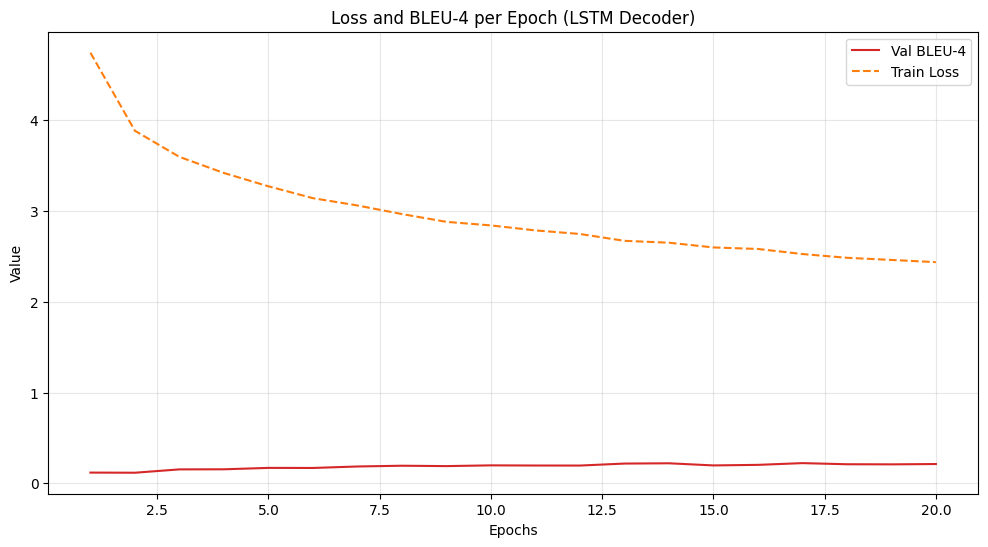

In [ ]:
# Exibe as métricas do treinamento
epochs_range = range(1, len(lstm_history['bleu']) + 1)
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, lstm_history['bleu'], label='Val BLEU-4', color='tab:red')
plt.plot(epochs_range, lstm_history['loss'], label='Train Loss', color='tab:orange', linestyle='--')

plt.title('Loss and BLEU-4 per Epoch (LSTM Decoder)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

<a name="5.3."></a>
### *5.3. GRU Decoder*

Esse *Decoder*, possui uma arquitetura semelhante à do *LSTM*, compartilhando o mesmo mecanismo de atenção. Entretanto, ele utiliza *"GRUCell's"*, que não utiliza *cell states*, apenas o *estado oculto* (h). Assim, o modelo possui menos parâmetros e é mais leve que o *LSTM*.

In [ ]:
# Classe para o Decoder GRU com Atenção
class GRU_Decoder(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.decode_step = nn.GRUCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_states(self, encoder_feats_mean):
        return self.init_h(encoder_feats_mean) # (batch, decoder_dim)

    def forward(self, encoder_feats, captions, lengths):
        batch_size = encoder_feats.size(0) # encoder_feats: (batch, encoder_dim, H, W)
        encoder_feats = encoder_feats.view(batch_size, self.encoder_dim, -1).permute(0, 2, 1) # (batch, num_pixels, encoder_dim)
        num_pixels = encoder_feats.size(1)
        vocab_size = self.fc.out_features

        embeddings = self.embedding(captions) # (batch, max_len, embed_dim)
        encoder_mean = encoder_feats.mean(dim=1) # (batch, encoder_dim)
        h = self.init_hidden_states(encoder_mean) # (batch, decoder_dim)

        max_len = captions.size(1)
        preds = torch.zeros(batch_size, max_len, vocab_size).to(encoder_feats.device)
        alphas = torch.zeros(batch_size, max_len, num_pixels).to(encoder_feats.device)

        for t in range(max_len):
            emb_t = embeddings[:, t, :]  # (batch, embed_dim) - teacher forcing
            att_weighted, alpha = self.attention(encoder_feats, h) # (batch, encoder_dim), (batch, num_pixels)
            gate = self.sigmoid(self.f_beta(h)) # (batch, encoder_dim)
            att_weighted = gate * att_weighted

            lstm_input = torch.cat([emb_t, att_weighted], dim=1) # (batch, embed_dim + encoder_dim)
            h = self.decode_step(lstm_input, h) # (batch, decoder_dim)
            preds[:, t, :] = self.fc(self.dropout(h))
            alphas[:, t, :] = alpha

        return preds, alphas

    def generate(self, encoder_feats, max_len=20):
        batch_size = encoder_feats.size(0)
        encoder_feats = encoder_feats.view(batch_size, self.encoder_dim, -1).permute(0, 2, 1)
        encoder_mean = encoder_feats.mean(dim=1)
        h = self.init_hidden_states(encoder_mean)

        results = [[] for _ in range(batch_size)]
        start_id = vocab.stoi['<start>']
        inputs = torch.tensor([start_id] * batch_size, device=encoder_feats.device, dtype=torch.long)
        embeddings = self.embedding(inputs) # (batch, embed_dim)

        for t in range(max_len):
            att_weighted, alpha = self.attention(encoder_feats, h)
            gate = self.sigmoid(self.f_beta(h))
            att_weighted = gate * att_weighted
            gru_input = torch.cat([embeddings, att_weighted], dim=1)

            h = self.decode_step(gru_input, h)
            output = self.fc(h)
            _, preds = output.max(dim=1) # greedy

            for i in range(batch_size): results[i].append(preds[i].item())
            embeddings = self.embedding(preds)
        return results

In [ ]:
# Cria o objeto e migra para a GPU (se disponível)
gru_decoder = GRU_Decoder(attention_dim, embed_dim, decoder_dim, encoder_dim=encoder_dim,
                          vocab_size=vocab_size, dropout=dropout).to(device)

# Otimizador e Função de Perda
optimizer = optim.Adam(gru_decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# Histórico e path do checkpoint
gru_history = {'loss': [], 'bleu': []}
checkpoint_path = os.path.join(save_path, "best_gru.pth")

In [ ]:
train_loop('GRU', checkpoint_path, gru_history, gru_decoder)

Epoch 01/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 01/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

====================| Epoch 01 finished | BLEU-4 = 0.1154 (New Checkpoint) |====================


Epoch 02/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 02/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

...

Epoch 19/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

============================| Epoch 19 finished | BLEU-4 = 0.2149 |============================


Epoch 20/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 20/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

============================| Epoch 20 finished | BLEU-4 = 0.2172 |============================

---------------------| "GRU" Decoder Training finished. Best BLEU: 0.2319 |---------------------


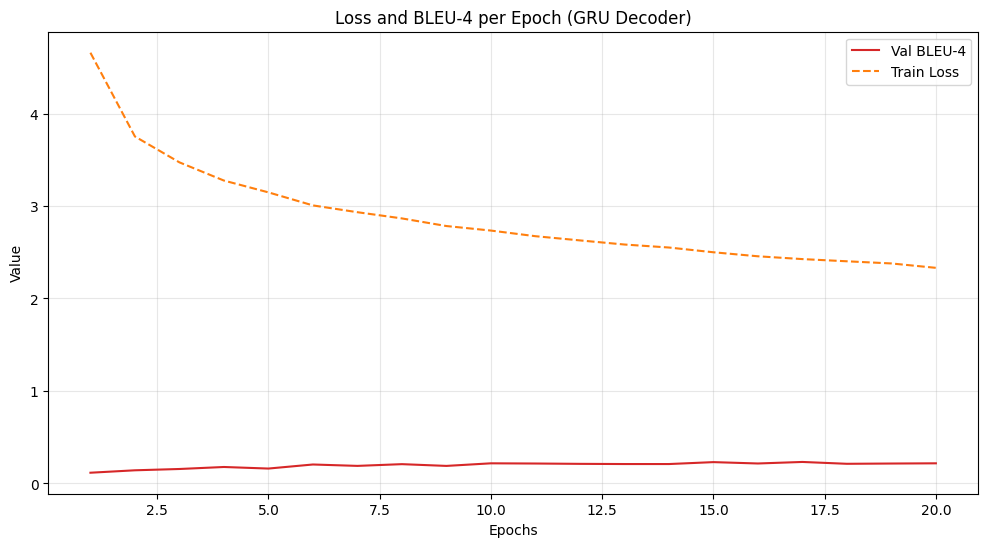

In [ ]:
# Exibe as métricas do treinamento
epochs_range = range(1, len(gru_history['bleu']) + 1)
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, gru_history['bleu'], label='Val BLEU-4', color='tab:red')
plt.plot(epochs_range, gru_history['loss'], label='Train Loss', color='tab:orange', linestyle='--')

plt.title('Loss and BLEU-4 per Epoch (GRU Decoder)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

<a name="5.4."></a>
### *5.4. Transformer Decoder*

Essa arquitetura de *Decoder* utiliza o mecanismo de atenção "multi-cabeça", que é capaz de aprender múltiplos padrões simultaneamente. Além disso, trabalha com *positional encoding*, que permite a paralelização do processamento. Essa última representa uma grande vantagem desse modelo. Assim como o *Decoder* *LSTM*, tende a possuir uma grande quantidade de parâmetros.

In [ ]:
# Positional Encoding (sinusoidal)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1) # (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        seq_len = x.size(0)
        return x + self.pe[:seq_len]

# Utilitary Functions
def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask # shape (sz, sz)

def create_padding_mask(seq, pad_idx):
    mask = (seq == pad_idx).to(seq.device)
    return mask.float().masked_fill(mask == True, float('-inf')).masked_fill(mask == False, float(0.0))

In [ ]:
# Classe para o Decoder Transformer
class Transformer_Decoder(nn.Module):
    def __init__(self, vocab_size, encoder_dim=2048, d_model=512, nhead=8, num_decoder_layers=6,
                 dim_feedforward=2048, dropout=0.1, max_len=50, pad_idx=0, device='cpu'):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.device = device

        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)
        self.encoder_feat_proj = nn.Linear(encoder_dim, d_model)
        self.max_patches = 64
        self.visual_pos_embedding = nn.Parameter(torch.randn(self.max_patches, d_model))


        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)

        self.fc_out = nn.Linear(d_model, vocab_size)
        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, encoder_feats, captions_input):
        device = encoder_feats.device
        B = encoder_feats.size(0)

        # 1) prepare src (visual)
        b, c, h, w = encoder_feats.shape
        N = h * w
        src = encoder_feats.view(b, c, N).permute(0, 2, 1) # (B, N, C)
        src = self.encoder_feat_proj(src) # (B, N, d_model)

        if N > self.max_patches: raise ValueError(f"Number of patches {N} > max_patches {self.max_patches}")
        pos_visual = self.visual_pos_embedding[:N, :].unsqueeze(1).repeat(1, B, 1) # (N, B, d_model)
        src = src.permute(1, 0, 2) # (N, B, d_model) - transformer expects (S,B,E)
        src = src + pos_visual # broadcast sum

        # 2) prepare tgt (text tokens)
        tgt = self.tok_embedding(captions_input) * math.sqrt(self.d_model) # (B, T, d_model)
        tgt = tgt.permute(1, 0, 2) # (T, B, d_model)
        tgt = self.positional_encoding(tgt)

        # 3) masks
        T = tgt.size(0)
        tgt_mask = generate_square_subsequent_mask(T, device) # (T, T)
        tgt_key_padding_mask = create_padding_mask(captions_input, self.pad_idx).to(device) # padding mask: shape (B, T)

        # 4) forward through transformer (src as memory)
        memory = src # (S,B,E)
        out = self.transformer(memory=memory, tgt=tgt, tgt_mask=tgt_mask,
                               tgt_key_padding_mask=tgt_key_padding_mask,
                               memory_key_padding_mask=None) # out: (T, B, d_model)
        out = out.permute(1, 0, 2) # (B, T, d_model)
        logits = self.fc_out(out) # (B, T, V)
        return logits

    def generate(self, encoder_feats, max_len=20):
        device = encoder_feats.device
        B = encoder_feats.size(0)
        b, c, h, w = encoder_feats.shape
        N = h * w

        src = encoder_feats.view(b, c, N).permute(0, 2, 1) # (B, N, C)
        src = self.encoder_feat_proj(src) # (B, N, d_model)
        if N > self.max_patches: raise ValueError("increase max_patches")
        pos_visual = self.visual_pos_embedding[:N, :].unsqueeze(1).repeat(1, B, 1)
        memory = src.permute(1, 0, 2) + pos_visual # (N, B, d_model)

        start_id, pad_id = vocab.stoi['<start>'], self.pad_idx # start tokens
        generated = torch.full((B, 1), start_id, dtype=torch.long, device=device) # (B, cur_len)

        results = [[] for _ in range(B)]
        for t in range(max_len):
            tgt = self.tok_embedding(generated) * math.sqrt(self.d_model) # (B, L, d)
            tgt = tgt.permute(1, 0, 2)  # (L, B, d)
            tgt = self.positional_encoding(tgt)
            tgt_mask = generate_square_subsequent_mask(tgt.size(0), device)

            out = self.transformer(memory=memory, tgt=tgt, tgt_mask=tgt_mask) # (L, B, d)
            out = out[-1, :, :] # last step (B, d_model)
            logits = self.fc_out(out) # (B, V)
            _, next_tokens = logits.max(dim=-1) # greedy

            generated = torch.cat([generated, next_tokens.unsqueeze(1)], dim=1) # (B, L+1)
            for i in range(B):
                token = next_tokens[i].item()
                results[i].append(token)
        return results

In [ ]:
# Cria o objeto e migra para a GPU (se disponível)
transformer_decoder = Transformer_Decoder(encoder_dim=encoder_dim, max_len=50, d_model=512, nhead=8, dim_feedforward=2048,
                                          num_decoder_layers=3, vocab_size=vocab_size, dropout=dropout).to(device)

# Otimizador e Função de Perda
optimizer = optim.Adam(transformer_decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# Histórico e path do checkpoint
transformer_history = {'loss': [], 'bleu': []}
checkpoint_path = os.path.join(save_path, "best_transformer.pth")

In [ ]:
train_loop('Transformer', checkpoint_path, transformer_history, transformer_decoder)

Epoch 01/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 01/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

====================| Epoch 01 finished | BLEU-4 = 0.0247 (New Checkpoint) |====================


Epoch 02/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 02/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

...

Epoch 19/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

====================| Epoch 19 finished | BLEU-4 = 0.2185 (New Checkpoint) |====================


Epoch 20/20 [train]:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 20/20  [val]:   0%|          | 0/51 [00:00<?, ?it/s]

============================| Epoch 20 finished | BLEU-4 = 0.2071 |============================

---------------------| "Transformer" Decoder Training finished. Best BLEU: 0.2185 |---------------------


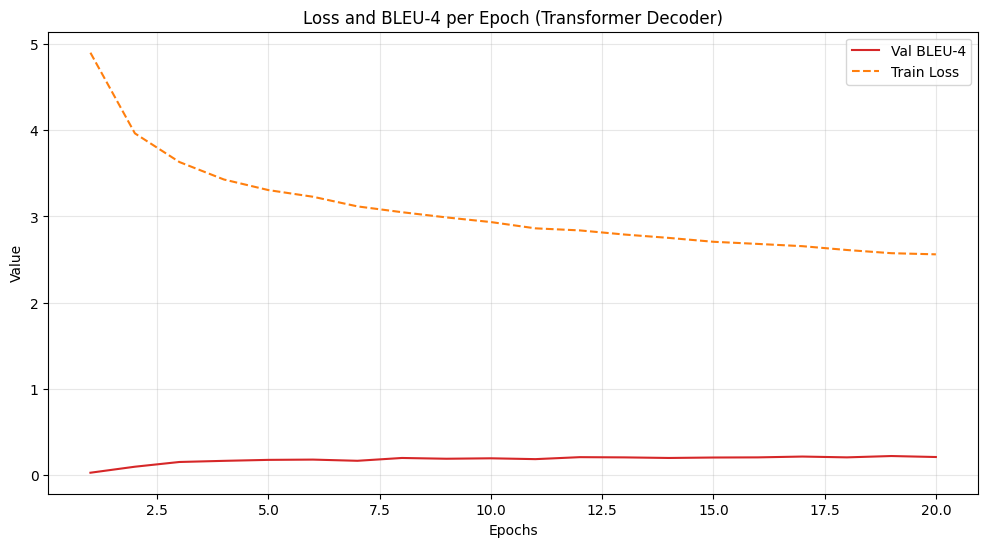

In [ ]:
# Exibe as métricas do treinamento
epochs_range = range(1, len(transformer_history['bleu']) + 1)
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, transformer_history['bleu'], label='Val BLEU-4', color='tab:red')
plt.plot(epochs_range, transformer_history['loss'], label='Train Loss', color='tab:orange', linestyle='--')

plt.title('Loss and BLEU-4 per Epoch (Transformer Decoder)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

<a name="6."></a>
## **6. Teste, Comparação e Resultados**

Após o desenvolvimento e treinamento dos três modelos de arquitetura para o *Decoder*, seguiremos para a etapa de teste e análise, que está organizada em subtópicos, da seguinte forma:

- [***6.1. Definições***](#6.1.);
- [***6.2. Teste de Previsão***](#6.2.);
- [***6.3. Comparação e Resultados***](#6.3.);
- [***6.4. Visualização Interativa***](#6.4.).

<a name="6.1."></a>
### **6.1. Definições**

Nas definições, estabelecemos as variáveis que serão utilizadas nesse tópico, bem como a função para predição dos modelos.

In [ ]:
# Paths dos checkpoints
lstm_path = "/content/flickr8k/models/best_lstm.pth"
gru_path = "/content/flickr8k/models/best_gru.pth"
transformer_path = "/content/flickr8k/models/best_transformer.pth"

results = {} # Dicionário de resultados do teste
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, reduction='sum') # Função de perda do teste

In [ ]:
# Função para predição do conjunto de teste
def evaluate_model(checkpoint_path, model_type, decoder):
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt['decoder_state_dict']
    decoder.to(device)

    try: decoder.load_state_dict(state_dict)
    except Exception: decoder.load_state_dict(ckpt['decoder_state_dict'])

    decoder.eval()
    total_nonpad_tokens, total_loss_sum = 0, 0.0
    all_refs, all_hyps = {}, {}

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Eval {model_type}"):
            images, captions_padded, lengths, img_names = batch
            images = images.to(device)
            captions_padded = captions_padded.to(device) # (B, T)
            lengths = lengths.to(device)

            with torch.no_grad(): encoder_out = encoder(images) # (B, C, H, W)
            targets = captions_padded[:, 1:].contiguous() # (B, T-1)
            captions_input = captions_padded[:, :-1].contiguous() # (B, T-1)

            if model_type in ('lstm', 'gru'):
                preds, _ = decoder(encoder_out, captions_input, lengths - 1)
                B, Tm1, V = preds.size()
                preds_flat = preds.view(-1, V) # (B*(T-1), V)
                targets_flat = targets.view(-1) # (B*(T-1))

                batch_loss_sum = criterion(preds_flat, targets_flat).item() # sum over non-pad tokens
                nonpad = (targets_flat != pad_idx).sum().item()
                total_loss_sum += batch_loss_sum
                total_nonpad_tokens += nonpad

                gen_ids_batch = decoder.generate(encoder_out, max_len=20) # list of lists
                for i, img_name in enumerate(img_names):
                    gen_ids = gen_ids_batch[i]
                    gen_words = decode_ids(gen_ids, vocab)
                    all_hyps[img_name], all_refs[img_name] = gen_words, captions[img_name]

            elif model_type == 'transformer':
                logits = decoder(encoder_out, captions_input) # (B, T-1, V)
                B, Tm1, V = logits.size()
                preds_flat = logits.view(-1, V)
                targets_flat = targets.view(-1)

                batch_loss_sum = criterion(preds_flat, targets_flat).item()
                nonpad = (targets_flat != pad_idx).sum().item()
                total_loss_sum += batch_loss_sum
                total_nonpad_tokens += nonpad

                gen_ids_batch = decoder.generate(encoder_out, max_len=20)
                for i, img_name in enumerate(img_names):
                    gen_ids = gen_ids_batch[i]
                    gen_words = decode_ids(gen_ids, vocab)
                    all_hyps[img_name], all_refs[img_name] = gen_words, captions[img_name]

    avg_loss_per_token = total_loss_sum / max(1, total_nonpad_tokens)
    bleu4 = compute_bleu(all_refs, all_hyps)
    return avg_loss_per_token, bleu4

<a name="6.2."></a>
### **6.2. Teste de Previsão**

Aqui, criamos instâncias das três arquiteturas de *Decoder*, e carregamos o checkpoint com melhor *BLEU* de cada uma, já passando o conjunto de teste (`test_loader`) para eles. Salvamos os resultados em um dicionário para análise no próximo subtópico.

In [ ]:
loaded_lstm = LSTM_Decoder(attention_dim, embed_dim, decoder_dim, encoder_dim=encoder_dim,
                           vocab_size=vocab_size, dropout=dropout).to(device)
loaded_gru = GRU_Decoder(attention_dim, embed_dim, decoder_dim, encoder_dim=encoder_dim,
                         vocab_size=vocab_size, dropout=dropout).to(device)
loaded_transformer = Transformer_Decoder(encoder_dim=encoder_dim, max_len=50, d_model=512, nhead=8, dim_feedforward=2048,
                                         num_decoder_layers=3, vocab_size=vocab_size, dropout=dropout).to(device)

loss_lstm, bleu_lstm = evaluate_model(lstm_path, 'lstm', loaded_lstm)
results['LSTM'] = (loss_lstm, bleu_lstm)

loss_gru, bleu_gru = evaluate_model(gru_path, 'gru', loaded_gru)
results['GRU'] = (loss_gru, bleu_gru)

loss_transformer, bleu_transformer = evaluate_model(transformer_path, 'transformer', loaded_transformer)
results['Transformer'] = (loss_transformer, bleu_transformer)

Eval lstm:   0%|          | 0/51 [00:00<?, ?it/s]

Eval gru:   0%|          | 0/51 [00:00<?, ?it/s]

Eval transformer:   0%|          | 0/51 [00:00<?, ?it/s]

<a name="6.3."></a>
### **6.3. Comparação e Resultados**

Finalmente, vamos plotar os resultados do teste (na célula a seguir) e da progressão do treinamento (na célula seguinte à próxima) de forma que possamos comparar o desempenho das três arquiteturas visualmente.

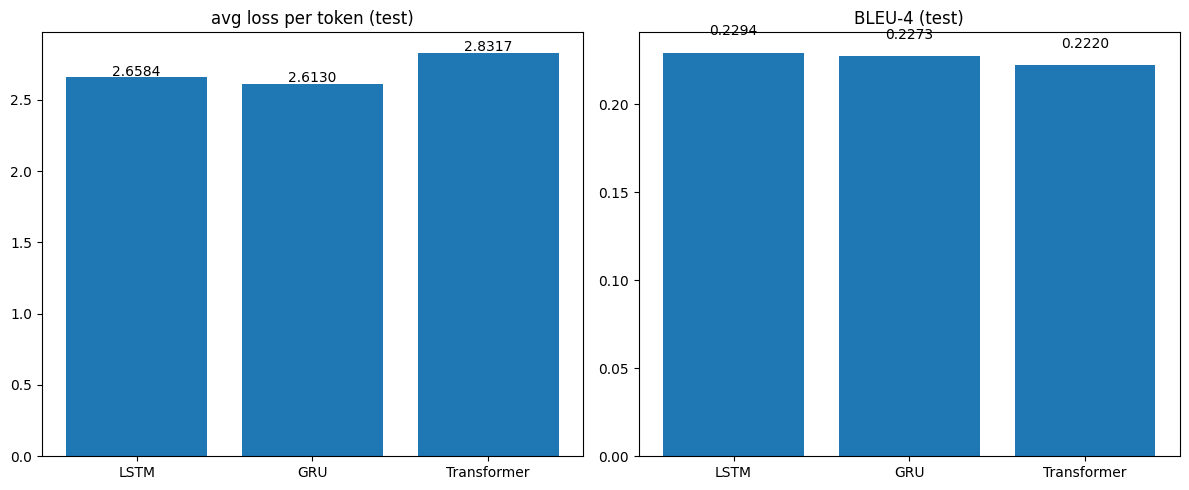

In [ ]:
models = list(results.keys())
losses = [results[m][0] for m in models]
bleus  = [results[m][1] for m in models]

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].bar(models, losses)
axes[0].set_title("avg loss per token (test)")
axes[1].bar(models, bleus)
axes[1].set_title("BLEU-4 (test)")

for ax in axes:
    for i, v in enumerate([losses, bleus][axes.tolist().index(ax)]):
        ax.text(i, v + (0.01 if axes.tolist().index(ax)==1 else 0.01), f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

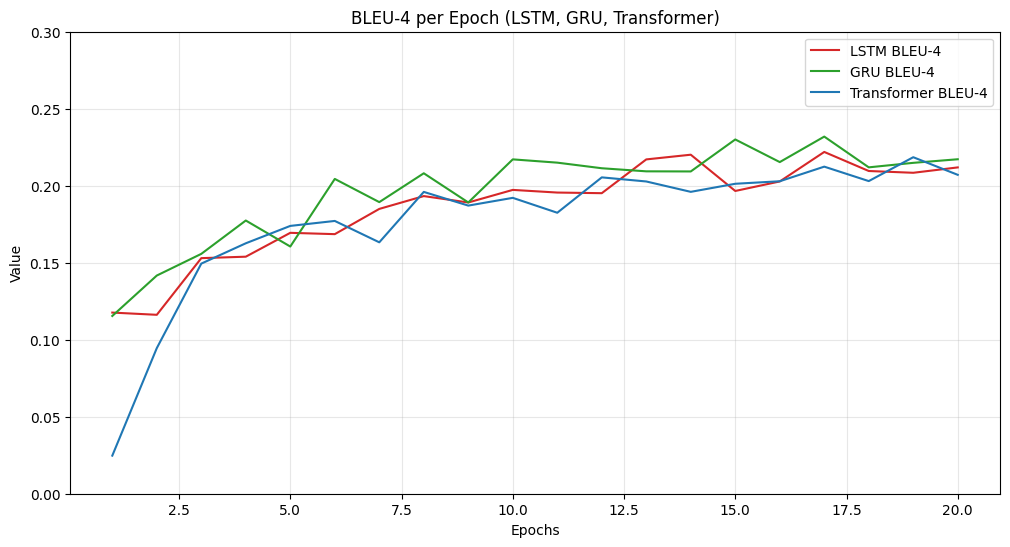

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, lstm_history['bleu'], label='LSTM BLEU-4', color='tab:red')
plt.plot(epochs_range, gru_history['bleu'], label='GRU BLEU-4', color='tab:green')
plt.plot(epochs_range, transformer_history['bleu'], label='Transformer BLEU-4', color='tab:blue')

plt.title('BLEU-4 per Epoch (LSTM, GRU, Transformer)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.ylim(0, 0.3)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Podemos perceber, em ambos os gráficos, que os modelos tiveram desempenhos parecidos. É possível inferir:

- O desempenho do *Decoder* com **Transformador** foi levemente abaixo dos outros *Decoders*. No conjunto de teste, tanto a sua *loss* ficou mais alta quanto o seu *BLEU* ficou mais baixo. Também, a sua *BLEU* teve a curva abaixo das outras na maioria das épocas.

- Ambos o *GRU* quanto o *LSTM* padrão tiveram desempenho semelhante, e seria errôneo dizer que um sobressaiu o outro. Não a toa, eles têm a arquitetura extremamente parecida, com a excessão de algumas linhas da classe.

- Com os parâmetros utilizados, e um *Encoder* padrão sem *fine-tuning* para todos os modelos, obteve-se uma máxima de 22,94% no *BLEU-4*, referente ao modelo *LSTM*. Nesse sentido, apesar de parecer um valor baixo em um primeiro momento, é importante compreender que, no escopo do nosso problema e com os parâmetros utilizados, trata-se de um resultado muito satisfatório e que torna esse modelo aplicável no mundo real, como será visto no subtópico seguinte.

<a name="6.4."></a>
### **6.4. Visualização Interativa**

Aqui, cada execução da célula seguinte irá separar duas imagens do conjunto de teste e gerará três legendas, cada uma advinda de um dos *Decoders*. Dessa forma, podemos observar diretamente a aplicabilidade e fidelidade desses modelos.

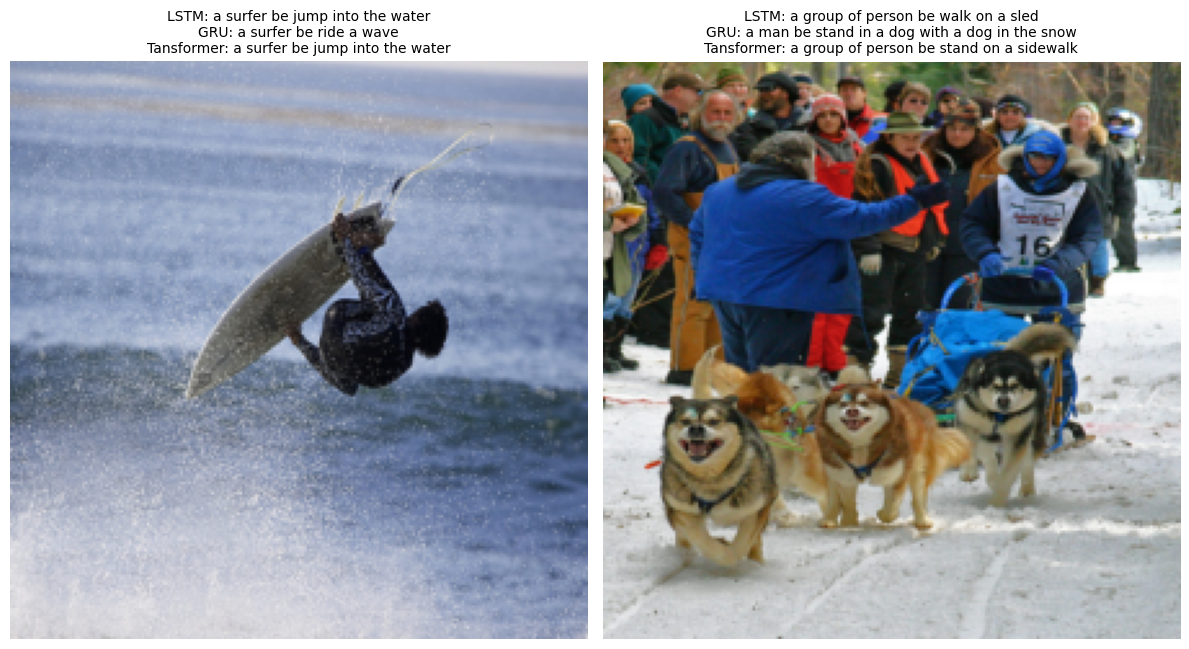

In [ ]:
# Seleciona uma amostra de 2 imagens do conjunto de teste
batch = next(iter(test_loader))
images_batch, captions_batch, lengths_batch, img_names_batch = batch
indices = random.sample(range(len(images_batch)), 2)

images_sel = [images_batch[i].to(device) for i in indices]
names_sel  = [img_names_batch[i] for i in indices]
preds_all = {'LSTM': [], 'GRU': [], 'Transformer': []}

# Passa as imagens ao encoder e aos três decoders
with torch.no_grad():
  for i, img_tensor in enumerate(images_sel):
    img_tensor = img_tensor.unsqueeze(0) # (1, C, H, W)
    enc_out = encoder(img_tensor) # (1, C, H, W)

    # LSTM
    ids_lstm = loaded_lstm.generate(enc_out, max_len=20)[0] # lista de ids
    sent_lstm = decode_ids(ids_lstm, vocab)
    preds_all['LSTM'].append(sent_lstm)
    # GRU
    ids_gru = loaded_gru.generate(enc_out, max_len=20)[0]
    sent_gru = decode_ids(ids_gru, vocab)
    preds_all['GRU'].append(sent_gru)
    # Transformer
    ids_trf = loaded_transformer.generate(enc_out, max_len=20)[0]
    sent_trf = decode_ids(ids_trf, vocab)
    preds_all['Transformer'].append(sent_trf)

# Plota as imagens com suas respectivas legendas previstas
fig, axes = plt.subplots(1, 2, figsize=(12,7))
for idx_plot, idx in enumerate(indices):
  ax = axes[idx_plot]
  img_t = images_batch[idx] # still normalized tensor on CPU
  img_vis = denormalize(img_t)
  img_vis = img_vis.permute(1,2,0).numpy()
  ax.imshow(img_vis)
  ax.axis('off')
  title_lines = [f"LSTM: {" ".join(preds_all['LSTM'][idx_plot])}",
                 f"GRU: {" ".join(preds_all['GRU'][idx_plot])}",
                 f"Tansformer: {" ".join(preds_all['Transformer'][idx_plot])}"]
  title_text = "\n".join(title_lines)
  ax.set_title(title_text, fontsize=10)

plt.tight_layout()
plt.show()

Perceba que as legendas, em sua maioria, são capazes de representar características gerais das imagens, como ambientes, pessoas, animais e até atividades de forma aceitável. Além disso, os três modelos tendem a apresentar palavras-chave semelhantes.

<a name="7."></a>
## **7. Conclusão**

Nesse atividade, foi desenvolvido um trabalho de *image captioning* em cima do *Dataset* *Flickr8k* [¹](#8.). Para isso, foi criada uma metodologia de desenvolvimento para esse notebook que envolvia uma linha de pesquisa online e a elaboração de código para um modelo composto de duas partes: um **Encoder**, uma rede pré-treinada importada do *PyTorch* e que seria comum aos integrantes da próxima parte: três arquiteturas diferentes de **Decoder**: **LSTM**, **GRU** e **Transformador**, a fim de que fossem comparados os resultados delas.

Com isso, foram desenvolvidas com sucesso essas múltiplas abordagens a fim de que, com a utilização da métrica *BLEU*, fosse feita uma seção de comparação entre os desempenhos, tanto de treino quanto de teste delas. Nesse sentido, obtiveram-se resultados muito próximos em todas elas, com uma *BLEU* próxima de **22%** ao longo de 20 épocas, que se traduz para um modelo capaz de extrair características relevantes da imagem. Assim, observou-se que houve muita semelhança entre essas arquiteturas para esse problema, de forma que apenas uma tivesse um desempenho levemente inferior (*Transformador*), mas ainda muito relevante.

<a name="8."></a>
## **8. Referências**

[[1]](#8.) **Flickr8k Dataset.** *GitHub*. Disponível em: *https://github.com/jbrownlee/Datasets/releases*

[[2]](#8.) **resnet50.** *PyTorch*. Disponível em: *https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html*